# 14 — High-gamma numerical convergence check (gamma_ij=24)

The locked GPU/discretization parameters (`N_min=128`, `panels_per_oscillation=40`,
`wall_points=20`, `how_often_ds=5`) were only validated at `gamma_ij<=8`
(`AI_HANDOFF.md`'s "Locked GPU Filon convergence parameters"). This checks
whether they still hold at `gamma_ij=24`, reusing the exact setup and
already-completed baseline result from `11_high_gamma_probe.ipynb` (~77
minutes at the locked values) as the reference point for three checks:

1. **`N_min` + `panels_per_oscillation` together** (coupled -- `N_min` is a
   floor that only bites when the panels-per-oscillation criterion alone
   would give too few panels) -- pure CLI flags, reuses the existing setup
   file unchanged.
2. **`wall_points`** -- baked into the setup file at generation time
   (sets `dz`), so this needs newly-generated setups at the same
   `gamma_ij=24` target.
3. **`how_often_ds`** -- also baked into the setup file (sets the saved
   field-snapshot stride). Tested by *decreasing* it (finer), not
   increasing -- higher `how_often_ds` means coarser sampling, the opposite
   semantics from the other two checks where higher = finer/more accurate.

`baby_steps` is explicitly excluded. Each check gets 4 new runs (the
existing baseline is reused as a 5th/reference point, not rerun) -- 12 new
jobs total, 3 nodes at 4 GPUs each.

In [1]:
from pathlib import Path
from types import SimpleNamespace

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import ptbuilder as pt
from ptbuilder.ic import BubbleMasterParams, write_2d_setup
from ptbuilder.weight_scan_diagnostics import load_kinematics

REPO_ROOT   = Path(pt.__file__).parent.parent
SCRIPTS_DIR = REPO_ROOT / 'scripts'
LOGS_DIR    = REPO_ROOT / 'logs'
SCRIPTS_DIR.mkdir(exist_ok=True)
LOGS_DIR.mkdir(exist_ok=True)

LAMBDA_BAR = 0.84

# Same domain as 11_high_gamma_probe.ipynb -- reused exactly so gamma_ij=24's
# kinematics (t_first, T_MAX, n_t, omega) reproduce that existing setup.
GAMMA_STAR_MIN    = 1.0
GAMMA_STAR_MAX    = 9.6
PAIR_GAMMA_FACTOR = 2.5
GAMMA_IJ_TARGET   = 24
DT                = 2

KR_MIN, KR_MAX = 1.0, 100.0
N_OMEGA = 32
N_K     = 51
TIME_FACTOR = 1.4

CUTOFF_TYPE = 0
BABY_STEPS  = 100   # locked, excluded from this check

# Locked production values (the existing baseline result, ~77 min, uses exactly these)
LOCKED = dict(n_min=128, ppw=40, wall_points=20, how_often_ds=5)

# New values for each check (baseline reused as reference, not rerun)
NMIN_PPW_JOINT   = [(160, 48), (192, 56), (256, 64), (320, 72)]
WALL_POINTS_NEW  = [24, 28, 32, 36]
HOW_OFTEN_DS_NEW = [4, 3, 2, 1]   # decreasing = finer

PROBE_ROOT      = REPO_ROOT / 'data/lb0.84_high_gamma_probe'
EXISTING_SETUP  = PROBE_ROOT / 'setups/g0024_dt2.h5'
BASELINE_OUTPUT = PROBE_ROOT / 'gpu/g0024_dt2'

CHECK_ROOT  = REPO_ROOT / 'data/lb0.84_high_gamma_convergence_check'
setup_dir   = CHECK_ROOT / 'setups'
output_root = CHECK_ROOT / 'gpu'
setup_dir.mkdir(parents=True, exist_ok=True)
output_root.mkdir(parents=True, exist_ok=True)

instanton_path = REPO_ROOT / f'data/phi4_lambda_bar{LAMBDA_BAR:g}/instanton.h5'
kin = load_kinematics(instanton_path)


class CachedPhi4Potential:
    def __init__(self, lambda_bar):
        self.params = {'lambda_bar': float(lambda_bar)}

    def to_hdf5(self, group):
        group.attrs.create('type', 'phi4', dtype=h5py.string_dtype(encoding='ascii'))
        group.attrs['phi_false'] = 0.0
        group.attrs['phi_true']  = 1.0
        group.attrs['lambda_bar'] = self.params['lambda_bar']


model = SimpleNamespace(instanton=kin.profile, kinematics=kin,
                        potential=CachedPhi4Potential(LAMBDA_BAR))


def time_at_gamma(gamma):
    if gamma <= 1.0:
        return 0.0
    return brentq(lambda t: float(kin.Gamma(t)) - gamma, 0.0, 1.0e7)


def rstar_at_gamma_star(gamma_star):
    t = time_at_gamma(gamma_star)
    return 2.0 * float(kin.R(t, r='mid'))

## 1. Recompute gamma_ij=24 kinematics -- verify against the existing setup

In [2]:
RSTAR_MAX = rstar_at_gamma_star(GAMMA_STAR_MAX)
T_MAX     = TIME_FACTOR * RSTAR_MAX
OMEGA_MIN = KR_MIN / RSTAR_MAX

t_first = time_at_gamma(GAMMA_IJ_TARGET)
n_t     = int(np.ceil((T_MAX - t_first) / DT)) + 1
times   = np.linspace(t_first, T_MAX, n_t)

smallest_target = max(GAMMA_STAR_MIN, GAMMA_IJ_TARGET / PAIR_GAMMA_FACTOR)
omega_max = KR_MAX / rstar_at_gamma_star(smallest_target)
omega = np.geomspace(OMEGA_MIN, omega_max, N_OMEGA)

print(f'recomputed: t_first={t_first:.3f}  T_MAX={T_MAX:.3f}  n_t={n_t}')

if not EXISTING_SETUP.exists():
    raise FileNotFoundError(
        f'{EXISTING_SETUP} not found -- run 11_high_gamma_probe.ipynb first.')

with h5py.File(EXISTING_SETUP) as f:
    print(f"existing setup:  t_cut={f.attrs['t_cut']:.3f}  t_max={f.attrs['t_max']:.3f}  "
          f"n_t={f.attrs['n_t']}  wall_points_target={f.attrs['wall_points_target']}  "
          f"how_often_ds={f.attrs['how_often_ds']}")
    assert int(f.attrs['n_t']) == n_t, 'n_t mismatch -- domain params drifted from the probe notebook'
print('Matches -- safe to reuse EXISTING_SETUP for the N_min/ppw check.')

recomputed: t_first=166.297  T_MAX=186.402  n_t=12
existing setup:  t_cut=359.514  t_max=429.420  n_t=12  wall_points_target=20.0  how_often_ds=5
Matches -- safe to reuse EXISTING_SETUP for the N_min/ppw check.


## 2. Generate new setups for the `wall_points` and `how_often_ds` checks

Same `gamma_ij=24` target, same `times`/`omega` grids as the existing setup
-- only `wall_points` or `how_often_ds` differs.

In [3]:
def write_variant(wall_points, how_often_ds, name):
    params = BubbleMasterParams(
        dz=None, wall_points=wall_points,
        n_w=N_OMEGA, n_k=N_K, how_often_ds=how_often_ds,
        baby_steps=BABY_STEPS, cutoff_type=CUTOFF_TYPE, t_0_scal=1.0,
        collision_radius='mid',
    )
    setup_path = setup_dir / f'{name}.h5'
    write_2d_setup(model, GAMMA_IJ_TARGET, times, setup_path, params, wlist=omega)
    return setup_path


new_setups = {}   # name -> path
for wp in WALL_POINTS_NEW:
    new_setups[f'wallpoints_{wp}'] = write_variant(wp, LOCKED['how_often_ds'], f'g0024_wp{wp}')
for hods in HOW_OFTEN_DS_NEW:
    new_setups[f'hods_{hods}'] = write_variant(LOCKED['wall_points'], hods, f'g0024_hods{hods}')

for name, path in new_setups.items():
    print(f'Written: {path.relative_to(REPO_ROOT)}')

Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp24.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp28.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp32.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_wp36.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_hods4.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_hods3.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_hods2.h5
Written: data/lb0.84_high_gamma_convergence_check/setups/g0024_hods1.h5


## 3. Build the run manifest (12 new jobs)

In [4]:
manifest_rows = []   # (check, label, setup_rel, param, ppw, out_name)

for n_min, ppw in NMIN_PPW_JOINT:
    out_name = f'nminppw_{n_min}_{ppw}'
    manifest_rows.append(('n_min_ppw', f'N_min={n_min},ppw={ppw}',
                          EXISTING_SETUP.relative_to(REPO_ROOT), n_min, ppw, out_name))

for wp in WALL_POINTS_NEW:
    out_name = f'wallpoints_{wp}'
    manifest_rows.append(('wall_points', f'wall_points={wp}',
                          new_setups[f'wallpoints_{wp}'].relative_to(REPO_ROOT),
                          LOCKED['n_min'], LOCKED['ppw'], out_name))

for hods in HOW_OFTEN_DS_NEW:
    out_name = f'hods_{hods}'
    manifest_rows.append(('how_often_ds', f'how_often_ds={hods}',
                          new_setups[f'hods_{hods}'].relative_to(REPO_ROOT),
                          LOCKED['n_min'], LOCKED['ppw'], out_name))

manifest = CHECK_ROOT / 'manifest.tsv'
manifest.write_text(
    'check\tlabel\tsetup\tparam\tppw\tname\n' +
    ''.join(f'{c}\t{l}\t{s}\t{p}\t{w}\t{n}\n' for c, l, s, p, w, n in manifest_rows)
)
print(f'{len(manifest_rows)} new runs written to {manifest.relative_to(REPO_ROOT)}')
for row in manifest_rows:
    print(' ', row)

12 new runs written to data/lb0.84_high_gamma_convergence_check/manifest.tsv
  ('n_min_ppw', 'N_min=160,ppw=48', PosixPath('data/lb0.84_high_gamma_probe/setups/g0024_dt2.h5'), 160, 48, 'nminppw_160_48')
  ('n_min_ppw', 'N_min=192,ppw=56', PosixPath('data/lb0.84_high_gamma_probe/setups/g0024_dt2.h5'), 192, 56, 'nminppw_192_56')
  ('n_min_ppw', 'N_min=256,ppw=64', PosixPath('data/lb0.84_high_gamma_probe/setups/g0024_dt2.h5'), 256, 64, 'nminppw_256_64')
  ('n_min_ppw', 'N_min=320,ppw=72', PosixPath('data/lb0.84_high_gamma_probe/setups/g0024_dt2.h5'), 320, 72, 'nminppw_320_72')
  ('wall_points', 'wall_points=24', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_wp24.h5'), 128, 40, 'wallpoints_24')
  ('wall_points', 'wall_points=28', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_wp28.h5'), 128, 40, 'wallpoints_28')
  ('wall_points', 'wall_points=32', PosixPath('data/lb0.84_high_gamma_convergence_check/setups/g0024_wp32.h5'), 128, 40, 'wallpoints_32')
  ('w

## 4. Generate SLURM script -- 3 nodes, 12 tasks, 4 GPUs each

Each task is a single one-shot run (unlike the dense-scan notebook, no
per-task looping needed -- 12 runs fit exactly into 3 nodes of 4 GPUs).

In [5]:
GPU_ACCOUNT      = 'm3166_g'
GPU_S_BATCH_SIZE = 128
GPU_WALLTIME     = '04:00:00'   # generous -- baseline at gamma_ij=24 was ~77 min; finer
                                # panels/wall_points/how_often_ds only add cost

manifest_rel = manifest.relative_to(REPO_ROOT)

# Three INDEPENDENT one-node jobs (not one combined 3-node job) -- each check
# can start as soon as its own single node is free, rather than the whole
# thing waiting in queue for 3 nodes to become available together.
script_paths = {}
for check in ('n_min_ppw', 'wall_points', 'how_often_ds'):
    rows = [r for r in manifest_rows if r[0] == check]
    script_path = SCRIPTS_DIR / f'lb0.84_high_gamma_convergence_check_{check}_gpu.sh'
    script_path.write_text(f'''#!/bin/bash
#SBATCH --job-name=bm_hg_{check}
#SBATCH --output={LOGS_DIR.relative_to(REPO_ROOT)}/bm_hg_{check}_%j.out
#SBATCH --constraint=gpu
#SBATCH --qos=regular
#SBATCH -A {GPU_ACCOUNT}
#SBATCH --nodes=1
#SBATCH --ntasks=4
#SBATCH --ntasks-per-node=4
#SBATCH --cpus-per-task=32
#SBATCH --gpus-per-task=1
#SBATCH --time={GPU_WALLTIME}
set -euo pipefail
REPO_ROOT="${{SLURM_SUBMIT_DIR:-$PWD}}"
cd "$REPO_ROOT"
pids=()
while IFS=$'\\t' read -r check_col label setup param ppw name; do
    [[ "$check_col" != "{check}" ]] && continue
    output="{output_root.relative_to(REPO_ROOT)}/${{name}}"
    mkdir -p "$output"
    /usr/bin/time --verbose srun --exclusive --exact -N 1 -n 1 -c 32 --gpus-per-task=1 --cpu-bind=cores bin/bubblemaster_gpu "$setup" "$output/" --param "$param" --filon-panels-per-osc "$ppw" --s-batch-size {GPU_S_BATCH_SIZE} &
    pids+=("$!")
done < {manifest_rel}
status=0
for pid in "${{pids[@]}}"; do
    wait "$pid" || status=1
done
exit "$status"
''')
    script_path.chmod(0o755)
    script_paths[check] = script_path
    print(f'Written: {script_path.relative_to(REPO_ROOT)}  ({len(rows)} tasks)')

print()
print('Submit all three independently:')
for check, sp in script_paths.items():
    print(f'  sbatch {sp.relative_to(REPO_ROOT)}')

Written: scripts/lb0.84_high_gamma_convergence_check_n_min_ppw_gpu.sh  (4 tasks)
Written: scripts/lb0.84_high_gamma_convergence_check_wall_points_gpu.sh  (4 tasks)
Written: scripts/lb0.84_high_gamma_convergence_check_how_often_ds_gpu.sh  (4 tasks)

Submit all three independently:
  sbatch scripts/lb0.84_high_gamma_convergence_check_n_min_ppw_gpu.sh
  sbatch scripts/lb0.84_high_gamma_convergence_check_wall_points_gpu.sh
  sbatch scripts/lb0.84_high_gamma_convergence_check_how_often_ds_gpu.sh


## 5. Load results -- compare each check against the existing baseline

Baseline = the already-completed gamma_ij=24 run at
`N_min=128, panels_per_oscillation=40, wall_points=20, how_often_ds=5`
(`11_high_gamma_probe.ipynb`, ~77 minutes). Only present once synced from
the cluster -- reports "NOT READY" gracefully otherwise, same as the other
notebooks.

In [6]:
def load_spectrum(out_dir, i_t=-1):
    '''Load the spectrum from the last (or given) result_*.h5 in out_dir.'''
    files = sorted(Path(out_dir).glob('result_*.h5'), key=lambda p: int(p.stem.split('_')[1]))
    if not files:
        raise FileNotFoundError(f'No result_*.h5 in {out_dir}')
    with h5py.File(files[i_t]) as f:
        return f['w'][:], f['spectrum'][:]


def rel_diff(ref, test, floor_frac=0.01):
    peak = np.abs(ref).max()
    mask = np.abs(ref) >= floor_frac * peak
    if not mask.any():
        return np.array([])
    return (test[mask] - ref[mask]) / ref[mask]


try:
    w_ref, spec_ref = load_spectrum(BASELINE_OUTPUT)
    print(f'Baseline loaded: {BASELINE_OUTPUT.relative_to(REPO_ROOT)}')
except FileNotFoundError as e:
    w_ref = spec_ref = None
    print(f'Baseline NOT READY: {e}')

# Collect everything (for the table AND the plots) keyed by check
by_check = {'n_min_ppw': [], 'wall_points': [], 'how_often_ds': []}

print()
print(f"{'check':>14}  {'label':>18}  {'max % vs baseline':>18}  {'mean %':>8}")
print('-' * 66)
for check, label, setup_rel, param, ppw, name in manifest_rows:
    out_dir = output_root / name
    try:
        w_test, spec_test = load_spectrum(out_dir)
        by_check[check].append((label, w_test, spec_test))
        if spec_ref is None:
            print(f"{check:>14}  {label:>18}  {'(no baseline)':>18}")
            continue
        spec_test_i = np.interp(w_ref, w_test, spec_test)
        rd = rel_diff(spec_ref, spec_test_i)
        m = np.abs(rd).max() * 100 if rd.size else float('nan')
        a = np.abs(rd).mean() * 100 if rd.size else float('nan')
        print(f"{check:>14}  {label:>18}  {m:>18.4f}  {a:>8.4f}")
    except FileNotFoundError:
        print(f"{check:>14}  {label:>18}  {'NOT READY':>18}")

Baseline NOT READY: No result_*.h5 in /Users/malte/Simulations/PhaseTransitionBuilder/data/lb0.84_high_gamma_probe/gpu/g0024_dt2

         check               label   max % vs baseline    mean %
------------------------------------------------------------------
     n_min_ppw    N_min=160,ppw=48           NOT READY
     n_min_ppw    N_min=192,ppw=56           NOT READY
     n_min_ppw    N_min=256,ppw=64           NOT READY
     n_min_ppw    N_min=320,ppw=72           NOT READY
   wall_points      wall_points=24           NOT READY
   wall_points      wall_points=28           NOT READY
   wall_points      wall_points=32           NOT READY
   wall_points      wall_points=36           NOT READY
  how_often_ds      how_often_ds=4           NOT READY
  how_often_ds      how_often_ds=3           NOT READY
  how_often_ds      how_often_ds=2           NOT READY
  how_often_ds      how_often_ds=1           NOT READY


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


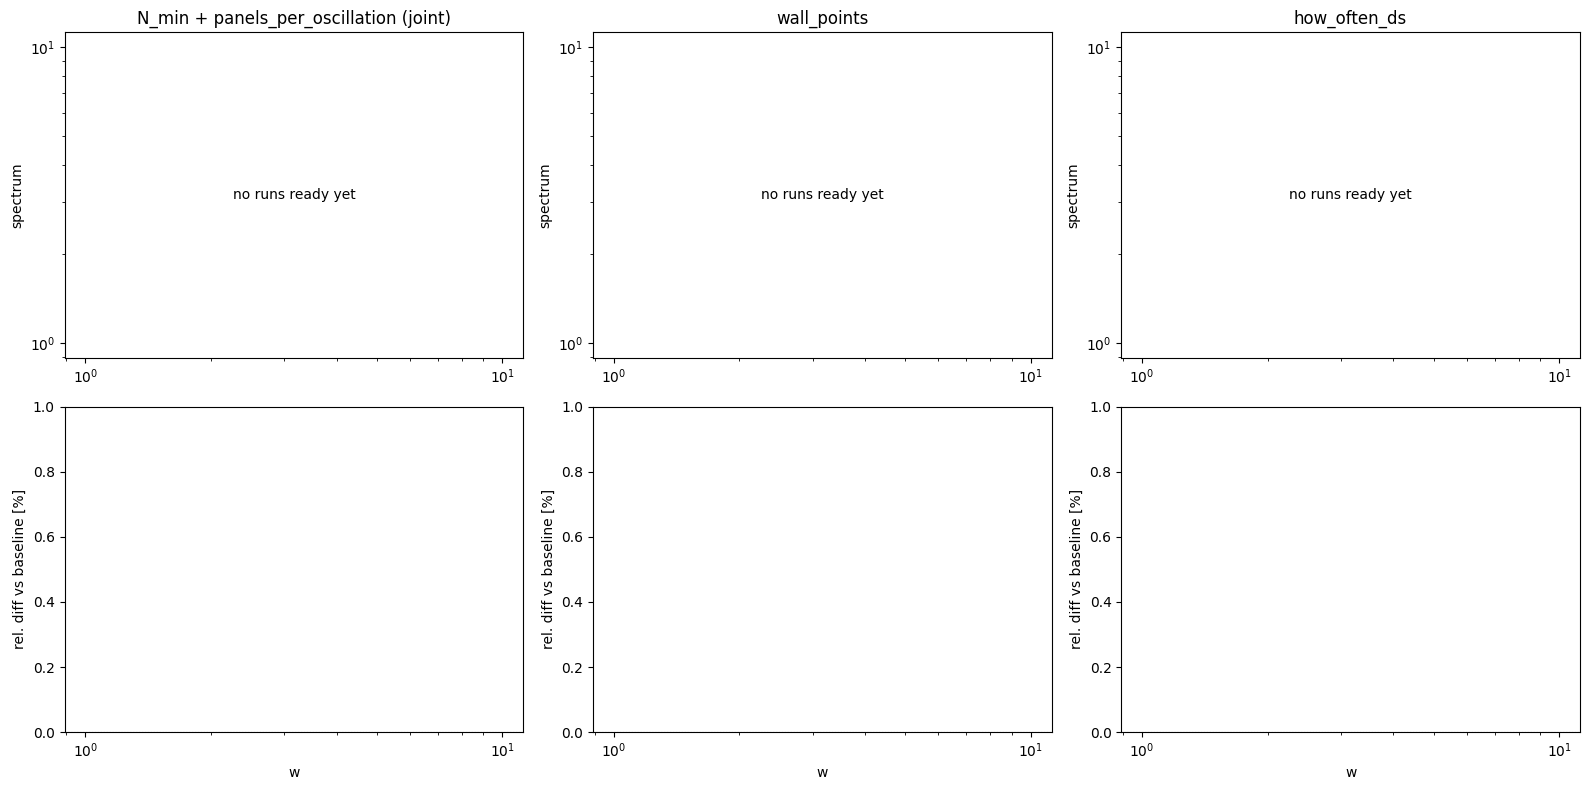

In [7]:
CHECK_TITLES = {
    'n_min_ppw':    'N_min + panels_per_oscillation (joint)',
    'wall_points':  'wall_points',
    'how_often_ds': 'how_often_ds',
}
COLORS4 = ['C0', 'C1', 'C2', 'C3']

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False)

for col, check in enumerate(('n_min_ppw', 'wall_points', 'how_often_ds')):
    ax_spec, ax_diff = axes[0, col], axes[1, col]
    entries = by_check[check]

    if spec_ref is not None:
        ax_spec.plot(w_ref, spec_ref, color='k', lw=2.2, label='baseline (locked)')

    if not entries:
        ax_spec.text(0.5, 0.5, 'no runs ready yet', ha='center', va='center',
                    transform=ax_spec.transAxes)
    for (label, w_test, spec_test), color in zip(entries, COLORS4):
        ax_spec.plot(w_test, spec_test, lw=1.4, ls='--', color=color, label=label)
        if spec_ref is not None:
            spec_test_i = np.interp(w_ref, w_test, spec_test)
            rd = (spec_test_i - spec_ref) / np.where(spec_ref != 0, spec_ref, np.nan)
            ax_diff.plot(w_ref, rd * 100, lw=1.4, color=color, label=label)

    ax_spec.set_xscale('log'); ax_spec.set_yscale('log')
    ax_spec.set_title(CHECK_TITLES[check])
    ax_spec.set_ylabel('spectrum')
    ax_spec.legend(frameon=False, fontsize=7)

    ax_diff.axhline(0, color='0.6', lw=0.8, ls=':')
    ax_diff.set_xscale('log')
    ax_diff.set_xlabel('w')
    ax_diff.set_ylabel('rel. diff vs baseline [%]')
    ax_diff.legend(frameon=False, fontsize=7)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'high_gamma_convergence_check.pdf', bbox_inches='tight')
plt.show()